In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [2]:
uploaded = files.upload()

image_name = next(iter(uploaded))
image_path = '/content/' + image_name

image = cv2.imread(image_path)
if image is None:
  raise ValueError('Image not loaded. Check the image file or format')

print('Image Shape:', image.shape)
print('Selected Image:', image_path)

Saving Practice Picture.jpg to Practice Picture.jpg
Image Shape: (5016, 5016, 3)
Selected Image: /content/Practice Picture.jpg


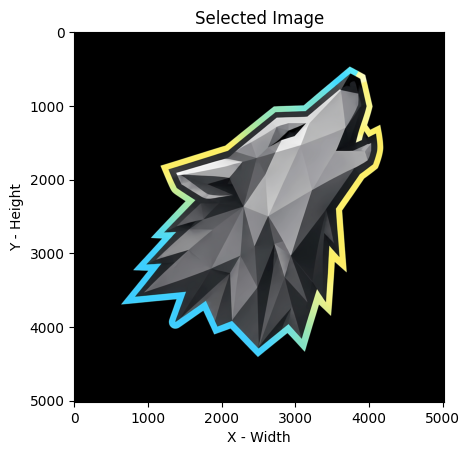

In [3]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.xlabel('X - Width')
plt.ylabel('Y - Height')
plt.title('Selected Image')
plt.show()

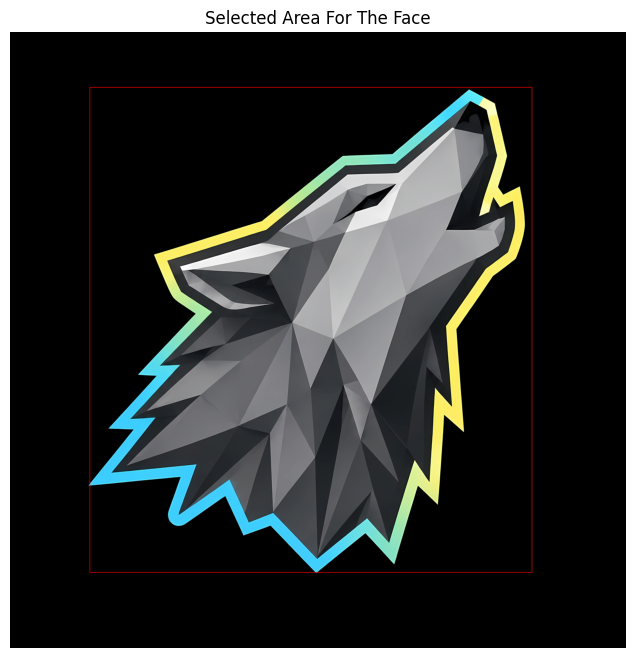

In [4]:
x1 = 650
y1 = 450
x2 = 4250
y2 = 4400

height, width = image.shape[:2]
if not (0 <= x1 < x2 <= width and 0 <= y1 < y2 <= height):
  raise ValueError('Invalid Coordinates For Cropping The Image')

preview = image_rgb.copy()
cv2.rectangle(preview, (x1, y1), (x2, y2), (255, 0, 0), 3)
plt.figure(figsize=(12, 8))
plt.imshow(preview)
plt.title('Selected Area For The Face')
plt.axis('off')
plt.show()

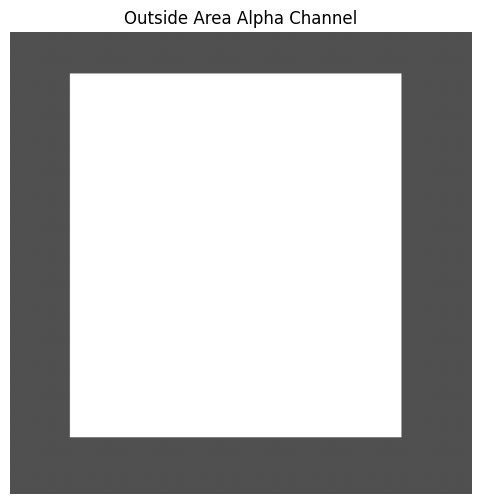

In [5]:
outside_alpha = 80

bgra_image = cv2.cvtColor(image, cv2.COLOR_BGR2BGRA)
bgra_image[:, :, 3] = outside_alpha

bgra_image[y1:y2, x1:x2, 3] = 255

plt.figure(figsize=(8, 6))
plt.imshow(bgra_image[:, :, 3], cmap='gray', vmin=0, vmax=255)
plt.title('Outside Area Alpha Channel')
plt.axis('off')
plt.show()

In [6]:
output_path = '/content/face_alpha.png'

success = cv2.imwrite(output_path, bgra_image)
if success:
  print(f'Image Saved To {output_path}')
else:
  print('Failed To Save The Image')

files.download(output_path)

Image Saved To /content/face_alpha.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>